In [36]:
import gymnasium as gym
env = gym.make("Blackjack-v1", sab=False)
nuber_of_actions = env.action_space.n

def basic_policy(obs):
    player_sum, dealer_card, usable_ace = obs
    return 0 if player_sum >= 17 else 1

def run_basic_policy(episodes=1000):
    wins = 0
    for episode in range(episodes):
        obs, info = env.reset()
        done = False
        while not done:
            action = basic_policy(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        if reward > 0:
            wins += 1
    return wins / episodes

print("Basic policy win rate:", run_basic_policy(), "≈ 39% expected")


Basic policy win rate: 0.398 ≈ 39% expected



Training config 1: Hidden=[64], Activation=ReLU

Training config 2: Hidden=[128, 128], Activation=ReLU

Training config 3: Hidden=[128, 128, 64], Activation=Tanh

Training config 4: Hidden=[256, 128, 64], Activation=LeakyReLU

Training config 5: Hidden=[64, 64, 64, 64], Activation=ReLU


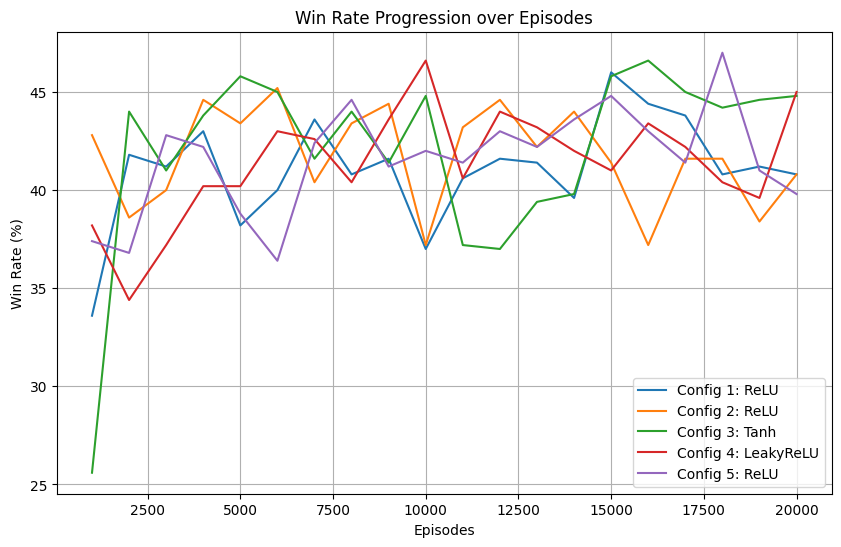


Best model saved with win rate: 47.00%
Best configuration: Hidden=[64, 64, 64, 64], Activation=ReLU, LR=0.001, Epsilon decay=0.9995


In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
best_overall_config = None


def obs_to_tensor(obs):
    return torch.tensor(obs, dtype=torch.float32)


def train_and_track(hidden_sizes, activation_fn, lr, eps_decay, episodes=20000, eval_every=1000):
    layers = []
    input_size = 3
    for h in hidden_sizes:
        layers.append(nn.Linear(input_size, h))
        layers.append(activation_fn())
        input_size = h
    layers.append(nn.Linear(input_size, nuber_of_actions))
    model = nn.Sequential(*layers)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    gamma = 0.9
    epsilon = 1.0
    epsilon_min = 0.1
    win_rates = []
    best_win_rate = 0.0
    best_model_state = None

    for ep in range(episodes):
        obs, info = env.reset()
        done = False
        while not done:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                q_values = model(obs_to_tensor(obs))
                action = torch.argmax(q_values).item()

            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            q_target = reward
            if not done:
                q_target += gamma * torch.max(model(obs_to_tensor(next_obs))).item()

            pred = model(obs_to_tensor(obs))[action]
            loss = loss_fn(pred, torch.tensor(q_target))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            obs = next_obs

        epsilon = max(epsilon_min, epsilon * eps_decay)

        
        if (ep + 1) % eval_every == 0:
            wins = 0
            eval_episodes = 500
            for _ in range(eval_episodes):
                obs, info = env.reset()
                done = False
                while not done:
                    with torch.no_grad():
                        q_values = model(obs_to_tensor(obs))
                    action = torch.argmax(q_values).item()
                    obs, reward, terminated, truncated, info = env.step(action)
                    done = terminated or truncated
                if reward > 0:
                    wins += 1
            win_rate = wins / eval_episodes
            win_rates.append(win_rate)


            if win_rate > best_win_rate:
                best_win_rate = win_rate
                best_model_state = model.state_dict()

    return win_rates, best_model_state, best_win_rate


configs = [
    {"hidden": [64], "act": nn.ReLU, "lr": 0.001, "eps_decay": 0.999},
    {"hidden": [128, 128], "act": nn.ReLU, "lr": 0.001, "eps_decay": 0.9995},
    {"hidden": [128, 128, 64], "act": nn.Tanh, "lr": 0.0005, "eps_decay": 0.9995},
    {"hidden": [256, 128, 64], "act": nn.LeakyReLU, "lr": 0.0005, "eps_decay": 0.9999},
    {"hidden": [64, 64, 64, 64], "act": nn.ReLU, "lr": 0.001, "eps_decay": 0.9995},
]

plt.figure(figsize=(10, 6))
best_overall_win_rate = 0
best_overall_model = None

for i, cfg in enumerate(configs, 1):
    print(f"\nTraining config {i}: Hidden={cfg['hidden']}, Activation={cfg['act'].__name__}")
    win_rates, best_model_state, best_win_rate = train_and_track(
        cfg["hidden"], cfg["act"], cfg["lr"], cfg["eps_decay"], episodes=20000, eval_every=1000
    )
    plt.plot(range(1000, len(win_rates)*1000 + 1, 1000), [r * 100 for r in win_rates],
             label=f"Config {i}: {cfg['act'].__name__}")

    if best_win_rate > best_overall_win_rate:
        best_overall_win_rate = best_win_rate
        best_overall_model = best_model_state
        best_overall_config = cfg


plt.title("Win Rate Progression over Episodes")
plt.xlabel("Episodes")
plt.ylabel("Win Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nBest model saved with win rate: {best_overall_win_rate*100:.2f}%")
print(f"Best configuration: Hidden={best_overall_config['hidden']}, Activation={best_overall_config['act'].__name__}, LR={best_overall_config['lr']}, Epsilon decay={best_overall_config['eps_decay']}")




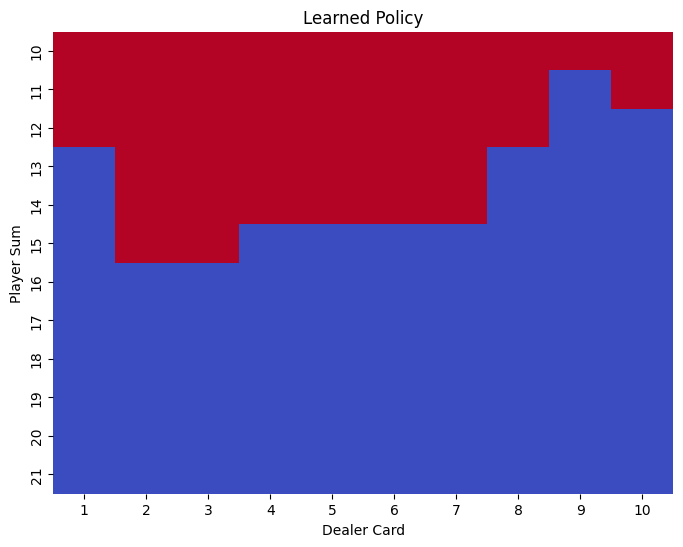

In [40]:
import numpy as np
import seaborn as sns

def plot_policy_heatmap(model, usable_ace=False):
    player_sums = range(10, 22)
    dealer_cards = range(1, 11)
    policy = np.zeros((len(player_sums), len(dealer_cards)))

    for i, ps in enumerate(player_sums):
        for j, dc in enumerate(dealer_cards):
            obs = (ps, dc, int(usable_ace))
            with torch.no_grad():
                q_values = model(obs_to_tensor(obs))
            action = torch.argmax(q_values).item()  # 0=stick, 1=hit
            policy[i, j] = action

    plt.figure(figsize=(8, 6))
    sns.heatmap(policy, xticklabels=dealer_cards, yticklabels=player_sums,
                cmap="coolwarm", cbar=False)
    plt.title(f"Learned Policy")
    plt.xlabel("Dealer Card")
    plt.ylabel("Player Sum")
    plt.show()


layers = []
input_size = 3
for h in best_overall_config["hidden"]:
    layers.append(nn.Linear(input_size, h))
    layers.append(best_overall_config["act"]())
    input_size = h
layers.append(nn.Linear(input_size, nuber_of_actions))

best_model = nn.Sequential(*layers)
best_model.load_state_dict(best_overall_model)
best_model.eval()
plot_policy_heatmap(best_model)